In [1]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

In [2]:
folder = "/work/bd0620/b309199/linear-mws"
flavor = "pmap_ld"
sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", f"{flavor}_MW_125km", f"{flavor}_MW_150km"]
regime_labels = ["$L$: 0.5$\\,$km", "$L$: 1$\\,$km", "$L$: 2$\\,$km", "$L$: 3$\\,$km", "$L$: 5$\\,$km", "$L$: 10$\\,$km", "$L$: 25$\\,$km", "$L$: 50$\\,$km", "$L$: 75$\\,$km", "$L$: 100$\\,$km", "$L$: 125$\\,$km", "$L$: 150$\\,$km"]

image_folder = f"../data/pmap"
os.makedirs(image_folder,exist_ok=True)

ds_list = []
cfgs = []
model = flavor.split("_")[0]
# tstamp = 299
tstamp = -1
for sim in sims:
    fpath = os.path.join(folder, sim)
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=tstamp, slices={"x": 0, "y": 0, "z": [0]})
        cfgs.append(cfg)
    else:   
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, tstamp, slices={"x": 0, "y": 0, "z": [0]})
    ds_list.append(ds)
# ds_list
# cfgs

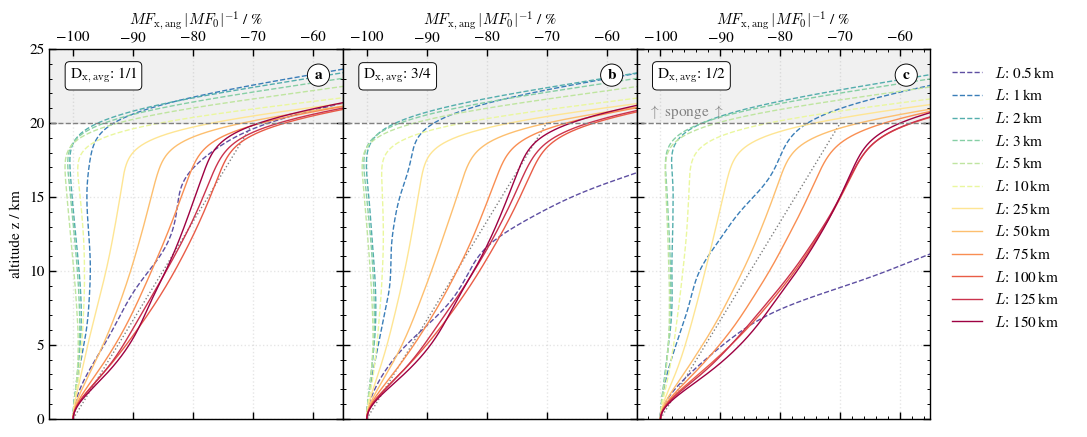

In [28]:
gskw = {'wspace':0, 'width_ratios': [4,4,4,2]}
fig, axes = plt.subplots(1,4,figsize=(11,4.5),sharey=True, gridspec_kw=gskw)

ax0 = axes[0]
ax1 = axes[1]
ax2 = axes[2]
ax3 = axes[3]
ax3.axis('off')

LINESTYLES = ['-'] * len(regime_labels)
LINESTYLES[0:6] = ['--'] * 6
COLS = plt.cm.tab10(np.linspace(0, 1, len(regime_labels)))

num_colors = len(sims)+1
cmap = plt.get_cmap('Spectral')
COLS = [cmap(i / (num_colors - 1)) for i in range(num_colors)]
COLS.pop(6)
# COLS.pop(6)
# COLS.pop(3)
COLS = COLS[::-1]

ZLIM = [0,25]


abs_factors = [1,2,3]
i=0
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)

    for j, abs_factor in enumerate(abs_factors):
        if model == "pmap":
            ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
            u0 = cfg['ambient_fields']['velocity_x']
            grav = cfg['constants']['gravity0']
            stb00 = cfg['ambient_fields']['stb00']
            N = np.sqrt(stb00*grav)
            rho00 = cfg['ambient_fields']['rho00']
            p00 = cfg['ambient_fields']['p00']
            # AMP = cfg['define_orography']['args']['amplitude']
            f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
            cap = cfg['constants']['cap']
    
            if cfg['absorber']['xboundaries']:
                nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
                nrelax1 = cfg['nx'] - nrelax0
            else:
                nrelax0 = 0
                nrelax1 = cfg['nx']
        else:
            _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
        
        zcr = ds['zcr'][:,0].values / 1000
    
        u = ds['u'].values
        uprime = u - u0
        v = ds['v'].values
        vprime = v
        w = ds['w'].values
        rho = ds['rho'].values
        th = ds['th'].values
        thprime = ds['thprime'].values
        p = ds['p'].values
        pprime = ds['pprime'].values
        
        the = th - thprime
        dthdz = np.gradient(the, cfg['dz'], axis=0)
        
        # --------- Calculate fluxes -------------------- # 
        uw   = w * uprime
        vw   = w * vprime
        mfx  = rho * uw
        mfx_ang = rho * (uw - f * vprime * thprime / dthdz)
        mfy  = rho * vw
        mfy_ang = rho * (vw + f * uprime * thprime / dthdz)
        MF_U = mfx * u + mfy * v # = -EFz
        MF_U_ang = mfx_ang * u + mfy_ang * v
        
        efx = uprime * pprime # h14, EFx1
        efy = vprime * pprime
        # efx = np.sqrt(efx**2+efy**2)
        efz = w * pprime # h13, EFz1
    
        tte = the * (p/p00)**cap # T_env (TODO: use pr0 instead of p)
        tloc = th * (p/p00)**cap # T
        # tte = the * (p/p00)**ds.cap # T_env (TODO: use pr0 instead of p)
        # tloc = th * (p/p00)**ds.cap # T
        tprime = tloc-tte
        
        ek = 1/2 * (uprime**2 + vprime**2 + w**2)
        ep = 1/2*(grav/N)**2 * (tprime/tte)**2 # * ds['rh0'][t,:,y,:] #  potential energy density
        # --------- Calculate fluxes -------------------- # 
            
        # -> horizontal mean
        # uw_m = uw[:,nrelax0:nrelax1].mean(axis=1)
        # vw_m = vw[:,nrelax0:nrelax1].mean(axis=1)
        mfx_m = mfx[:,nrelax0:nrelax1].mean(axis=1)
        mfx_ang_m = mfx_ang[:,nrelax0:nrelax1].mean(axis=1)
        mfy_m = mfy[:,nrelax0:nrelax1].mean(axis=1)
        mfy_ang_m = mfy_ang[:,nrelax0:nrelax1].mean(axis=1)
        ep_m = ep[:,nrelax0:nrelax1].mean(axis=1)
        ek_m = ek[:,nrelax0:nrelax1].mean(axis=1)
        efx_m = efx[:,nrelax0:nrelax1].mean(axis=1)
        efy_m = efy[:,nrelax0:nrelax1].mean(axis=1)
        efz_m = efz[:,nrelax0:nrelax1].mean(axis=1)
        MF_U_m = MF_U[:,nrelax0:nrelax1].mean(axis=1)
        MF_U_ang_m = MF_U_ang[:,nrelax0:nrelax1].mean(axis=1)
        
         # --- 1D filter --- #
        dz = 50
        lambdaz = 6250
    
        mfx_m = filter.gaussian_filter_fft_1D(mfx_m, lambdaz, dz)
        mfx_ang_m = filter.gaussian_filter_fft_1D(mfx_ang_m, lambdaz, dz)
        mfy_m = filter.gaussian_filter_fft_1D(mfy_m, lambdaz, dz)
        mfy_ang_m = filter.gaussian_filter_fft_1D(mfy_ang_m, lambdaz, dz)
    
        ep_m = filter.gaussian_filter_fft_1D(ep_m, lambdaz, dz)
        efx_m = filter.gaussian_filter_fft_1D(efx_m, lambdaz, dz)
        efy_m = filter.gaussian_filter_fft_1D(efy_m, lambdaz, dz)
        efz_m = filter.gaussian_filter_fft_1D(efz_m, lambdaz, dz)
        MF_U_m = filter.gaussian_filter_fft_1D(MF_U_m, lambdaz, dz)
        MF_U_ang_m = filter.gaussian_filter_fft_1D(MF_U_ang_m, lambdaz, dz)
        ek_m = filter.gaussian_filter_fft_1D(ek_m, lambdaz, dz)
    
        delta_ep = (-efz_m-MF_U_m)/efz_m[0]*100
        delta_ep_ang = (-efz_m-MF_U_ang_m)/efz_m[0]*100
    
        lw = 1
        var = 1000 * (mfx_ang_m)
        ref = np.abs(var[0])
        var_per = 100 * var / ref if ref != 0 else np.zeros_like(var)
    
        axes[j].plot(var_per, zcr, lw=lw, ls=LINESTYLES[i], color=COLS[i], label=regime_labels[i])

    i+=1
    
# -- FORMAT AXES -- #
ax0.set_xlabel(r'$MF_\mathrm{x,ang} \, |MF_0|^{-1}$ / %')
ax1.set_xlabel(r'$MF_\mathrm{x,ang} \, |MF_0|^{-1}$ / %')
ax2.set_xlabel(r'$MF_\mathrm{x,ang} \, |MF_0|^{-1}$ / %')

ax0.yaxis.set_minor_locator(AutoMinorLocator())

# - SPONGE LAYER - #
lw_ax = 1
lw_sponge = 1
hsponge = 20
sponge_label = r'$\uparrow$ sponge $\uparrow$'
# ax2.text(0.7, 0.65, sponge_label, transform=ax2.transAxes, color='grey')
ax2.text(0.04, 0.82, sponge_label, transform=ax2.transAxes, color='grey')

c3 = 'lightgrey'
htop = 32
alpha_sponge = 0.33
symb_ax = '-'
col_ax = 'lightgrey'

# --- Labels and legend --- #
# ax2.legend(loc='outside upper right', framealpha=1, fontsize=11) # 'upper left'
# ax5.axis('off')
handles, labels = ax2.get_legend_handles_labels()

fig.legend(handles, labels, loc="upper center", framealpha=0,
           bbox_to_anchor=(0.92, 0.87))

ax0.set_ylim(ZLIM)
ax0.set_ylabel(r'altitude z / km')

# --- Text --- #
labs = ['a','b','c']
for ax, lab in zip(axes[:-1], labs):
    ax.set_xlim(-104, -55)
    ax.plot([-100, -70], [0, 20], linewidth=1, color='grey', ls= 'dotted', zorder=1)
    ax.text(1-0.07, 0.92, lab, horizontalalignment='right', transform=ax.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    # ax.tick_params(axis="y", which='both', direction="inout", right=False)
    ax.tick_params(axis="x", which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis="y", which='both', direction="in", right=True)
    ax.tick_params(axis="x", which='both', top=True, bottom=True)
    ax.grid(visible=True)

    if ax in [ax2]:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    
    ax.fill_between(ax.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)
    ax.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)
    ax.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)
    ax.axhline(y=hsponge, lw=lw_sponge, ls='--', color='grey',zorder=0)

ax0.text(0.07, 0.92, r'D$_\mathrm{x,avg}$: 1/1', horizontalalignment='left', transform=ax0.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax1.text(0.07, 0.92, r'D$_\mathrm{x,avg}$: 3/4', horizontalalignment='left', transform=ax1.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax2.text(0.07, 0.92, r'D$_\mathrm{x,avg}$: 1/2', horizontalalignment='left', transform=ax2.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

# --- Save figure --- #
fig.tight_layout()
fig_title = f'vp_mfxang_temp.png'
# fig_title = f'vertical_profiles_legend.png'
fig.savefig(os.path.join(image_folder, fig_title), facecolor='w', edgecolor='w',
                    format='png', dpi=300, bbox_inches='tight')

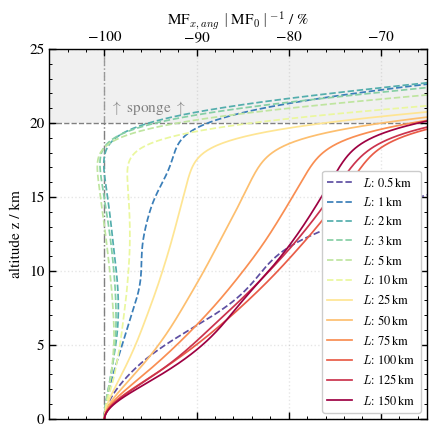

In [5]:
gskw = {'wspace': 0}
# Keep per-panel proportions close to the old 3-panel layout.
fig, ax = plt.subplots(1, 1, figsize=(4.5,4.5), sharey=True, gridspec_kw=gskw)

ZLIM = [0,25]
LINESTYLES = ['-'] * len(regime_labels)
LINESTYLES[0:6] = ['--'] * 6
COLS = plt.cm.tab10(np.linspace(0, 1, len(regime_labels)))

num_colors = len(sims)+1
cmap = plt.get_cmap('Spectral')
COLS = [cmap(i / (num_colors - 1)) for i in range(num_colors)]
COLS.pop(6)
# COLS.pop(6)
# COLS.pop(3)
COLS = COLS[::-1]

abs_factor = 2
for i, ds in enumerate(ds_list):
    cfg = cfgs[i]

    u0 = cfg['ambient_fields']['velocity_x']
    grav = cfg['constants']['gravity0']
    stb00 = cfg['ambient_fields']['stb00']
    N = np.sqrt(stb00 * grav)
    rho00 = cfg['ambient_fields']['rho00']
    p00 = cfg['ambient_fields']['p00']
    f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0'] * np.pi / 180)
    cap = cfg['constants']['cap']

    if cfg['absorber']['xboundaries']:
        nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
        nrelax1 = cfg['nx'] - nrelax0
    else:
        nrelax0 = 0
        nrelax1 = cfg['nx']

    wprime = ds['w'].values
    zcr = ds['zcr'][:, 0].values / 1000
    rho = ds['rho'].values

    u = ds['u'].values
    uprime = u - u0
    v = ds['v'].values
    vprime = v
    w = ds['w'].values

    th = ds['th'].values
    thprime = ds['thprime'].values
    p = ds['p'].values
    pprime = ds['pprime'].values

    the = th - thprime
    dthdz = np.gradient(the, cfg['dz'], axis=0)

    uw = w * uprime
    vw = w * vprime
    mfx = rho * uw
    mfx_ang = rho * (uw - f * vprime * thprime / dthdz)
    mfy = rho * vw
    mfy_ang = rho * (vw + f * uprime * thprime / dthdz)
    MF_U = mfx * u + mfy * v
    MF_U_ang = mfx_ang * u + mfy_ang * v

    efx = uprime * pprime
    efy = vprime * pprime
    efz = w * pprime

    tte = the * (p / p00) ** cap
    tloc = th * (p / p00) ** cap
    tprime = tloc - tte

    ek = 1 / 2 * (uprime ** 2 + vprime ** 2 + w ** 2)
    ep = 1 / 2 * (grav / N) ** 2 * (tprime / tte) ** 2

    mfx_m = mfx[:, nrelax0:nrelax1].mean(axis=1)
    mfx_ang_m = mfx_ang[:, nrelax0:nrelax1].mean(axis=1)
    mfy_m = mfy[:, nrelax0:nrelax1].mean(axis=1)
    mfy_ang_m = mfy_ang[:, nrelax0:nrelax1].mean(axis=1)
    mf_ang_m = (mfx_ang[:, nrelax0:nrelax1] + mfy_ang[:, nrelax0:nrelax1]).mean(axis=1)
    ep_m = ep[:, nrelax0:nrelax1].mean(axis=1)
    ek_m = ek[:, nrelax0:nrelax1].mean(axis=1)
    efx_m = efx[:, nrelax0:nrelax1].mean(axis=1)
    efy_m = efy[:, nrelax0:nrelax1].mean(axis=1)
    efz_m = efz[:, nrelax0:nrelax1].mean(axis=1)
    MF_U_m = MF_U[:, nrelax0:nrelax1].mean(axis=1)
    MF_U_ang_m = MF_U_ang[:, nrelax0:nrelax1].mean(axis=1)

    dz = 50
    lambdaz = 6250

    mfx_m = filter.gaussian_filter_fft_1D(mfx_m, lambdaz, dz)
    mfx_ang_m = filter.gaussian_filter_fft_1D(mfx_ang_m, lambdaz, dz)
    mfy_m = filter.gaussian_filter_fft_1D(mfy_m, lambdaz, dz)
    mfy_ang_m = filter.gaussian_filter_fft_1D(mfy_ang_m, lambdaz, dz)
    mf_ang_m = filter.gaussian_filter_fft_1D(mf_ang_m, lambdaz, dz)

    ep_m = filter.gaussian_filter_fft_1D(ep_m, lambdaz, dz)
    efx_m = filter.gaussian_filter_fft_1D(efx_m, lambdaz, dz)
    efy_m = filter.gaussian_filter_fft_1D(efy_m, lambdaz, dz)
    efz_m = filter.gaussian_filter_fft_1D(efz_m, lambdaz, dz)
    MF_U_m = filter.gaussian_filter_fft_1D(MF_U_m, lambdaz, dz)
    MF_U_ang_m = filter.gaussian_filter_fft_1D(MF_U_ang_m, lambdaz, dz)
    ek_m = filter.gaussian_filter_fft_1D(ek_m, lambdaz, dz)

    lw = 1.25
    var = 1000 * (mfx_ang_m)
    ref = np.abs(var[0])
    var_per = 100 * var / ref if ref != 0 else np.zeros_like(var)

    ax.plot(var_per, zcr, lw=lw, ls=LINESTYLES[i], color=COLS[i], label=regime_labels[i])

ax.set_xlim(-106, -65)

ax.yaxis.set_minor_locator(AutoMinorLocator())

lw_sponge = 1
hsponge = 20
sponge_label = r'$\uparrow$ sponge $\uparrow$'
ax.text(0.16, 0.83, sponge_label, transform=ax.transAxes, color='grey')

c3 = 'lightgrey'
htop = 32
alpha_sponge = 0.33

symb_ax = '-'
col_ax = 'lightgrey'
lw_ax = 1

ax.set_ylim(ZLIM)
ax.set_ylabel(r'altitude z / km')

ax.legend(loc='lower right', framealpha=1, fontsize=9)

# ax.text(
#     0.055,
#     0.92,
#     flavor_labels[0],
#     horizontalalignment='left',
#     transform=ax.transAxes,
#     weight='bold',
#     bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"},
# )
ax.set_xlabel('MF$_{x,ang}\\, \\mid$MF$_0 \\mid^{-1}$ / %')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis="y", which='both', direction="inout", right=True)
ax.tick_params(axis="x", which='both', top=True, labeltop=True, bottom=True,labelbottom=False)
ax.xaxis.set_label_position('top')
ax.fill_between(ax.get_xlim(), [hsponge, hsponge], [htop, htop], facecolor=c3, alpha=alpha_sponge)
ax.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax, ls=symb_ax, color=col_ax)
ax.axhline(y=hsponge, lw=lw_sponge, ls='--', color='grey',zorder=0)
ax.axvline(x=-100, lw=lw_sponge, ls='-.', color='grey',zorder=0)
ax.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax, ls=symb_ax, color=col_ax)
ax.tick_params(axis="y", which='both', direction="in")

# ax.text(
#     1 - 0.05,
#     0.93,
#     'a',
#     horizontalalignment='right',
#     transform=ax.transAxes,
#     weight='bold',
#     bbox={"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"},
# )
ax.grid(visible=True)

fig.tight_layout()
fig_title = f'vertical_profiles_across_scales_temp.png'
fig.savefig(
    os.path.join(image_folder, fig_title),
    facecolor='w',
    edgecolor='w',
    format='png',
    dpi=300,
    bbox_inches='tight',
)
